# Falke MR Strategy Research

Simulate MR strategy on historical Polymarket data, grid-search params, train ML, export ONNX.

```bash
python download_markets.py --start 2026-03-01 --end 2026-03-20
python download_prices.py --min-volume 100
jupyter notebook analysis.ipynb
```

In [3]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
DATA_DIR = Path('data')
print('Imports OK')

Imports OK


## 1. Load Data

In [4]:
def load_all_pairs():
    all_markets, all_prices = [], {}
    for mf in sorted(DATA_DIR.glob('*-markets.json')):
        prefix = mf.stem.replace('-markets', '')
        pf = DATA_DIR / f'{prefix}-prices.json'
        if not pf.exists():
            continue
        with open(mf) as f:
            all_markets.extend(json.load(f))
        with open(pf) as f:
            all_prices.update(json.load(f))
    print(f'Markets: {len(all_markets)}, price tokens: {len(all_prices)}')
    return all_markets, all_prices


markets, prices = load_all_pairs()

# --- Quick diagnostics ---
with_history = sum(1 for v in prices.values() if v.get('history'))
print(f'Tokens with price history: {with_history}')

sample_finals = [float(v['history'][-1]['p']) for v in list(prices.values())[:500] if v.get('history')]
if sample_finals:
    resolved = sum(1 for p in sample_finals if p >= 0.99 or p <= 0.01)
    print(f'Sample 500 — resolved (p≈0/1): {resolved} ({resolved/len(sample_finals):.0%})')
    print(f'Final price: min={min(sample_finals):.3f}  median={np.median(sample_finals):.3f}  max={max(sample_finals):.3f}')
    if resolved / len(sample_finals) < 0.3:
        print('WARNING: most final prices are mid-value — 1w window may not cover resolution.')
        print('Fix: re-run download_prices.py and change interval=1w to interval=max in fetch_price_history()')

Markets: 109575, price tokens: 53178
Tokens with price history: 9272
Sample 500 — resolved (p≈0/1): 24 (100%)
Final price: min=0.001  median=0.500  max=1.000


## 2. Helper Functions

In [11]:
def get_final_price(history):
    return float(history[-1]['p']) if history else None


def get_topic(market):
    return market.get('topic') or market.get('category') or 'unknown'


def get_market_type(market):
    n = len(market.get('tokens', []))
    return 'binary' if n == 2 else ('multi' if n > 2 else market.get('marketType', 'binary'))


def get_market_volume(market):
    return float(market.get('volumeNum') or market.get('volume') or 0)


def compute_pct_changes(history, window_minutes):
    """O(n) two-pointer: for each point find the price exactly window_minutes ago."""
    result = []
    left = 0
    for i, point in enumerate(history):
        ts = int(point['t'])
        price = float(point['p'])
        window_start = ts - window_minutes * 60
        # Advance left pointer until history[left] is within window
        while left < i and int(history[left]['t']) < window_start:
            left += 1
        if left == i:
            continue  # no point old enough yet
        past_price = float(history[left]['p'])
        if past_price == 0:
            continue
        result.append({'ts': ts, 'price': price, 'pct_change': (price - past_price) / past_price})
    return result


def price_volatility(history, window=60):
    recent = [float(h['p']) for h in history[-window:]]
    if len(recent) < 2:
        return 0.0
    returns = np.diff(recent) / np.array(recent[:-1])
    return float(np.std(returns))


def simulate_mr(markets, prices, threshold=0.20, window_hours=1.0,
                min_volume=0.0, price_min=0.05, price_max=0.95):
    """Simulate MR signals. Replicates src/strategy/mean_reversion.rs exactly."""
    window_minutes = int(window_hours * 60)

    token_to_market = {}
    for m in markets:
        for t in m.get('tokens', []):
            tid = t.get('token_id', '')
            if tid:
                token_to_market[tid] = m

    complement_of = {}
    for m in markets:
        toks = [t.get('token_id', '') for t in m.get('tokens', []) if t.get('token_id')]
        if len(toks) == 2:
            complement_of[toks[0]] = toks[1]
            complement_of[toks[1]] = toks[0]

    signals = []
    for token_id, pdata in prices.items():
        history = pdata.get('history', [])
        if not history:
            continue
        market = token_to_market.get(token_id)
        if not market:
            continue
        if get_market_volume(market) < min_volume:
            continue

        final_price = get_final_price(history)
        if final_price is None:
            continue

        comp_id = complement_of.get(token_id)
        comp_history = prices.get(comp_id, {}).get('history', []) if comp_id else []
        comp_final = get_final_price(comp_history) if comp_history else None

        # Build a fast lookup: ts -> comp_price for complement history
        comp_price_by_ts = {}
        if comp_history:
            last = None
            for h in comp_history:
                last = float(h['p'])
                comp_price_by_ts[int(h['t'])] = last

        used = set()
        for row in compute_pct_changes(history, window_minutes):
            ts, price, pct = row['ts'], row['price'], row['pct_change']
            if price < price_min or price > price_max:
                continue
            if abs(pct) < threshold:
                continue
            bucket = (token_id, ts // (window_minutes * 60))
            if bucket in used:
                continue
            used.add(bucket)

            if pct > 0:  # price rose → buy complement
                if not comp_id or comp_final is None:
                    continue
                # Get complement price at or before ts
                entry = None
                for h in comp_history:
                    if int(h['t']) <= ts:
                        entry = float(h['p'])
                    else:
                        break
                if entry is None or entry < price_min or entry > price_max:
                    continue
                bet_final = comp_final
                direction = 'fade_rise'
            else:  # price fell → buy this outcome
                entry = price
                bet_final = final_price
                direction = 'fade_fall'

            signals.append({
                'condition_id': market.get('conditionId', ''),
                'question': market.get('question', ''),
                'ts': ts,
                'entry_price': entry,
                'pct_change': pct,
                'abs_pct_change': abs(pct),
                'direction': direction,
                'volume_usd': get_market_volume(market),
                'market_type': get_market_type(market),
                'topic': get_topic(market),
                'volatility': price_volatility(history),
                'final_price': bet_final,
                'resolved_win': 1 if bet_final >= 0.99 else 0,
            })

    df = pd.DataFrame(signals)
    if not df.empty:
        df['entry_datetime'] = pd.to_datetime(df['ts'], unit='s')
    return df


print('Helper functions ready')

Helper functions ready


## 3. Baseline Simulation

In [12]:
df_base = simulate_mr(markets, prices, threshold=0.20, window_hours=1.0, min_volume=0)
print(f'Signals: {len(df_base)}')
if not df_base.empty:
    print(f'Win rate: {df_base["resolved_win"].mean():.1%}')
    print(f'Direction: {df_base["direction"].value_counts().to_dict()}')
    print(f'resolved_win: {df_base["resolved_win"].value_counts().to_dict()}')
    print(f'final_price sample: {df_base["final_price"].value_counts().head(5).to_dict()}')
    df_base.head()

Signals: 6376
Win rate: 41.2%
Direction: {'fade_rise': 3274, 'fade_fall': 3102}
resolved_win: {0: 3751, 1: 2625}
final_price sample: {0.0005: 3286, 0.9995: 2550, 0.5: 64, 0.095: 35, 0.1: 33}


## 4. Grid Search: threshold × window_hours

In [13]:
import gc

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.75, 0.90]
windows    = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 12.0, 24.0]

grid_results = []

for win in windows:
    # Precompute at min threshold to cap DataFrame size
    df_win = simulate_mr(markets, prices, threshold=min(thresholds),
                         window_hours=win, min_volume=0)
    print(f'window={win:5.1f}h  raw signals: {len(df_win)}')

    if df_win.empty:
        for thr in thresholds:
            grid_results.append({'threshold': thr, 'window_hours': win, 'n_signals': 0,
                                  'win_rate': float('nan'), 'expected_pnl_per_bet': float('nan')})
        del df_win
        gc.collect()
        continue

    # Precompute pnl column once (vectorized)
    ep = df_win['entry_price'].values
    rw = df_win['resolved_win'].values
    df_win['_pnl'] = np.where(rw, 1.0 / ep - 1.0, -1.0)
    ac = df_win['abs_pct_change'].values

    for thr in thresholds:
        mask = ac >= thr
        n = mask.sum()
        if n == 0:
            grid_results.append({'threshold': thr, 'window_hours': win, 'n_signals': 0,
                                  'win_rate': float('nan'), 'expected_pnl_per_bet': float('nan')})
            continue
        win_rate = rw[mask].mean()
        pnl      = df_win['_pnl'].values[mask].mean()
        grid_results.append({'threshold': thr, 'window_hours': win, 'n_signals': int(n),
                              'win_rate': float(win_rate), 'expected_pnl_per_bet': float(pnl)})
        print(f'  thr={thr:.2f}  n={n:5d}  win={win_rate:.1%}  E[pnl]={pnl:+.3f}')

    del df_win, ep, rw, ac
    gc.collect()

grid_df = pd.DataFrame(grid_results)
filled = grid_df['expected_pnl_per_bet'].notna().sum()
print(f'\nDone — {filled}/{len(grid_df)} cells have data')

window=  0.2h  raw signals: 21
  thr=0.05  n=   21  win=47.6%  E[pnl]=+0.249
  thr=0.10  n=   13  win=46.2%  E[pnl]=+0.644
  thr=0.15  n=    5  win=40.0%  E[pnl]=-0.488
  thr=0.20  n=    1  win=100.0%  E[pnl]=+0.493
  thr=0.30  n=    1  win=100.0%  E[pnl]=+0.493
  thr=0.40  n=    1  win=100.0%  E[pnl]=+0.493
window=  0.5h  raw signals: 21
  thr=0.05  n=   21  win=47.6%  E[pnl]=+0.249
  thr=0.10  n=   13  win=46.2%  E[pnl]=+0.644
  thr=0.15  n=    5  win=40.0%  E[pnl]=-0.488
  thr=0.20  n=    1  win=100.0%  E[pnl]=+0.493
  thr=0.30  n=    1  win=100.0%  E[pnl]=+0.493
  thr=0.40  n=    1  win=100.0%  E[pnl]=+0.493
window=  1.0h  raw signals: 16911
  thr=0.05  n=16911  win=42.9%  E[pnl]=-0.048
  thr=0.10  n=10550  win=41.7%  E[pnl]=-0.049
  thr=0.15  n= 8002  win=41.6%  E[pnl]=-0.061
  thr=0.20  n= 6376  win=41.2%  E[pnl]=-0.074
  thr=0.30  n= 4378  win=39.9%  E[pnl]=-0.141
  thr=0.40  n= 3018  win=39.8%  E[pnl]=-0.158
  thr=0.50  n= 2099  win=38.7%  E[pnl]=-0.185
  thr=0.60  n= 1566  win

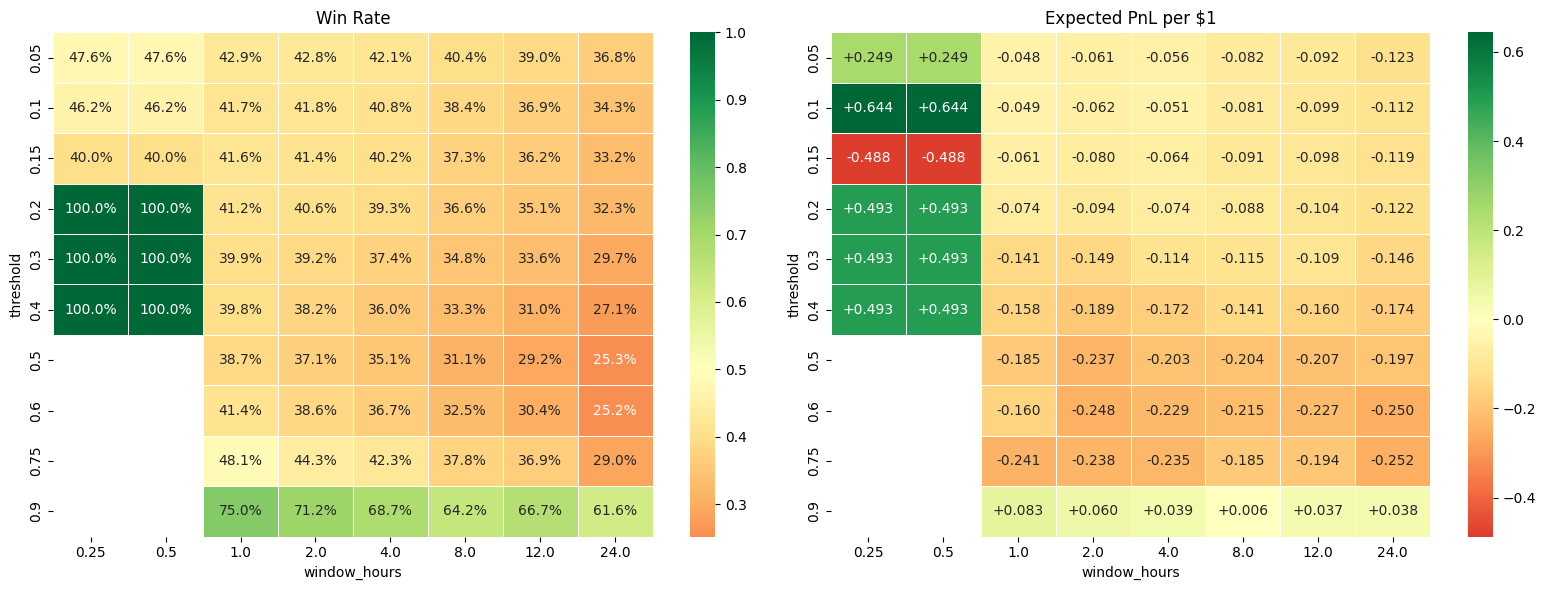

Top combos by E[pnl]:
 threshold  window_hours  n_signals  win_rate  expected_pnl_per_bet
       0.1          0.25         13  0.461538              0.643930
       0.1          0.50         13  0.461538              0.643930
       0.3          0.25          1  1.000000              0.492537
       0.2          0.25          1  1.000000              0.492537
       0.4          0.25          1  1.000000              0.492537


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, metric, title, fmt in [
    (axes[0], 'win_rate',           'Win Rate',              '.1%'),
    (axes[1], 'expected_pnl_per_bet','Expected PnL per $1', '+.3f'),
]:
    pivot = grid_df.pivot(index='threshold', columns='window_hours', values=metric)
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap='RdYlGn',
                center=0 if 'pnl' in metric else 0.5, ax=ax, linewidths=0.5)
    ax.set_title(title)
plt.tight_layout()
plt.savefig('grid_search.png', dpi=150)
plt.show()

print('Top combos by E[pnl]:')
print(grid_df.dropna().sort_values('expected_pnl_per_bet', ascending=False).head(5).to_string(index=False))

## 5. Feature Engineering + ML

In [16]:
df_ml = simulate_mr(markets, prices, threshold=0.05, window_hours=1.0, min_volume=0)
print(f'ML dataset: {len(df_ml)} signals')
if df_ml.empty:
    raise ValueError('No signals — check that price data covers market resolution.')

le_dir   = LabelEncoder()
le_topic = LabelEncoder()
le_mtype = LabelEncoder()
df_ml['direction_enc']    = le_dir.fit_transform(df_ml['direction'])
df_ml['topic_enc']        = le_topic.fit_transform(df_ml['topic'].fillna('unknown'))
df_ml['market_type_enc']  = le_mtype.fit_transform(df_ml['market_type'])
df_ml['log_volume']       = np.log1p(df_ml['volume_usd'])
df_ml['dist_from_50']     = (df_ml['entry_price'] - 0.5).abs()
df_ml['potential_payout'] = 1.0 / df_ml['entry_price'].clip(0.01, 0.99)

FEATURES = ['abs_pct_change', 'entry_price', 'dist_from_50', 'potential_payout',
            'log_volume', 'volatility', 'direction_enc', 'topic_enc', 'market_type_enc']

X = df_ml[FEATURES].fillna(0)
y = df_ml['resolved_win']
print(f'Class balance: {y.value_counts().to_dict()}  Win rate: {y.mean():.1%}')

ML dataset: 16911 signals
Class balance: {0: 9649, 1: 7262}  Win rate: 42.9%


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y==0).sum()/(y==1).sum(), eval_metric='logloss',
    random_state=42, verbosity=0)
xgb_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc')
print(f'XGBoost  AUC (row-split):  {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}')

rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')
print(f'RandomForest AUC (row-split): {rf_scores.mean():.4f} ± {rf_scores.std():.4f}')

# --- Market-based split to avoid leakage ---
# Same market can generate multiple signals; if it appears in both train+test,
# the model learns market-specific quirks, not generalizable patterns.
unique_markets = df_ml['condition_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_markets)
split = int(len(unique_markets) * 0.8)
train_markets = set(unique_markets[:split])
test_markets  = set(unique_markets[split:])

train_mask = df_ml['condition_id'].isin(train_markets)
test_mask  = df_ml['condition_id'].isin(test_markets)

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'\nMarket-based split: {train_mask.sum()} train signals ({len(train_markets)} markets) '
      f'/ {test_mask.sum()} test signals ({len(test_markets)} markets)')

xgb_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

for name, model in [('XGBoost', xgb_model), ('RandomForest', rf_model)]:
    prob = model.predict_proba(X_test)[:, 1]
    auc  = roc_auc_score(y_test, prob)
    print(f'{name} test AUC (market-split): {auc:.4f}')

XGBoost  AUC (row-split):  0.8940 ± 0.0079
RandomForest AUC (row-split): 0.8658 ± 0.0096

Market-based split: 13359 train signals (1688 markets) / 3552 test signals (423 markets)
XGBoost test AUC (market-split): 0.8400
RandomForest test AUC (market-split): 0.8193


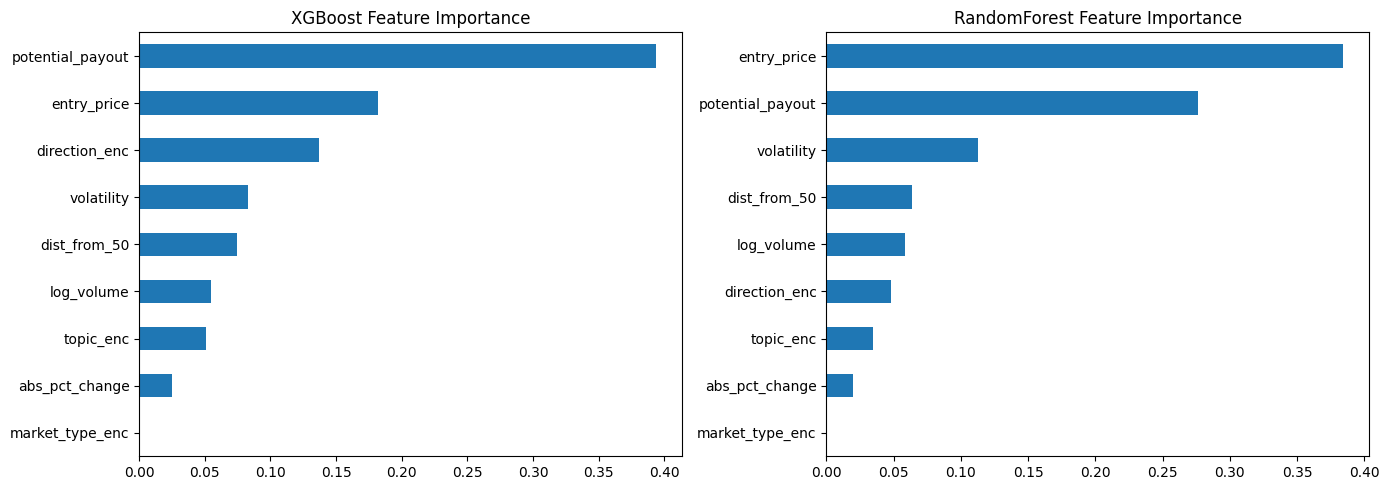

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, model) in zip(axes, [('XGBoost', xgb_model), ('RandomForest', rf_model)]):
    pd.Series(model.feature_importances_, index=FEATURES).sort_values().plot.barh(ax=ax)
    ax.set_title(f'{name} Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 6. ML-Filtered PnL vs Naive

In [27]:
df_test = df_ml[test_mask].copy()
df_test['xgb_prob'] = xgb_model.predict_proba(X_test)[:, 1]
df_test['rf_prob']  = rf_model.predict_proba(X_test)[:, 1]
df_test['pnl'] = np.where(df_test['resolved_win'], 1.0/df_test['entry_price'] - 1.0, -1.0)

print(f'Test set: {len(df_test)} signals from {len(test_markets)} unseen markets\n')
for label, col, thr in [
    ('All signals (naive)', None, None),
    ('XGBoost > 0.55',  'xgb_prob', 0.55),
    ('XGBoost > 0.60',  'xgb_prob', 0.60),
    ('RF > 0.55',       'rf_prob',  0.55),
    ('RF > 0.60',       'rf_prob',  0.60),
]:
    sub = df_test[df_test[col] > thr] if col else df_test
    if len(sub) == 0:
        print(f'{label}: 0 signals'); continue
    print(f'{label:28s}: n={len(sub):4d}  win={sub["resolved_win"].mean():.1%}  '
          f'total={sub["pnl"].sum():+.2f}  avg={sub["pnl"].mean():+.4f}')

Test set: 3552 signals from 423 unseen markets

All signals (naive)         : n=3552  win=44.2%  total=-137.23  avg=-0.0386
XGBoost > 0.55              : n=1496  win=73.3%  total=+218.34  avg=+0.1459
XGBoost > 0.60              : n=1269  win=76.4%  total=+184.88  avg=+0.1457
RF > 0.55                   : n=1382  win=72.1%  total=+59.56  avg=+0.0431
RF > 0.60                   : n=1150  win=75.7%  total=+40.67  avg=+0.0354


## 7. Export ONNX

Rust usage: load with `ort` crate, input `features: [[f32; 9]]`, output `[labels, probabilities]`, use `probabilities[0][1]` as win probability.

In [28]:
from onnxmltools import convert_xgboost, convert_sklearn
from onnxmltools.convert.common.data_types import FloatTensorType as OnnxFloat
from skl2onnx.common.data_types import FloatTensorType

best_name  = 'XGBoost' if xgb_scores.mean() >= rf_scores.mean() else 'RandomForest'
best_model = xgb_model if best_name == 'XGBoost' else rf_model
print(f'Exporting: {best_name}')

n_feat = len(FEATURES)

if best_name == 'XGBoost':
    onnx_path = 'mr_classifier_xgboost.onnx'
    # onnxmltools requires numeric feature names (f0, f1, ...) — clear them temporarily
    booster = best_model.get_booster()
    saved_names = booster.feature_names
    booster.feature_names = None
    onnx_model = convert_xgboost(best_model, initial_types=[('features', OnnxFloat([None, n_feat]))])
    booster.feature_names = saved_names
    with open(onnx_path, 'wb') as f:
        f.write(onnx_model.SerializeToString())
    print(f'Saved: {onnx_path}')
else:
    onnx_path = 'mr_classifier_randomforest.onnx'
    onnx_model = convert_sklearn(
        best_model, name='MRClassifier',
        initial_types=[('features', FloatTensorType([None, n_feat]))],
        options={id(best_model): {'zipmap': False}})
    with open(onnx_path, 'wb') as f:
        f.write(onnx_model.SerializeToString())
    print(f'Saved: {onnx_path}')

# Save feature metadata for Rust
with open('mr_classifier_meta.json', 'w') as f:
    json.dump({
        'features': FEATURES,
        'model': best_name,
        'n_features': n_feat,
        'topic_mapping': {v: int(i) for i, v in enumerate(le_topic.classes_)},
        'direction_mapping': {v: int(i) for i, v in enumerate(le_dir.classes_)},
        'market_type_mapping': {v: int(i) for i, v in enumerate(le_mtype.classes_)},
    }, f, indent=2)
print('Saved: mr_classifier_meta.json')

# Verify with onnxruntime
import onnxruntime as ort
sess = ort.InferenceSession(onnx_path)
inp_name = sess.get_inputs()[0].name
sample = X_test[:3].astype(np.float32).values
out = sess.run(None, {inp_name: sample})
print(f'ONNX input name: "{inp_name}"')
print(f'ONNX outputs: {[o.shape for o in out]}')
probs = out[1][:, 1] if len(out) > 1 and np.array(out[1]).ndim == 2 else out[0]
print(f'Win probs (ONNX):  {probs}')
print(f'Win probs (model): {best_model.predict_proba(X_test[:3])[:, 1]}')

Exporting: XGBoost
Saved: mr_classifier_xgboost.onnx
Saved: mr_classifier_meta.json
ONNX input name: "features"
ONNX outputs: [(3,), (3, 2)]
Win probs (ONNX):  [0.8387649  0.04964101 0.58500594]
Win probs (model): [0.8387649  0.04964102 0.58500594]
